# Star Type Classifier

###Set-up and Uploading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


###Data Processing

In [6]:
df = pd.read_csv("data/Stars.csv")
df

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Blue,O,5
236,30839,834042.000000,1194.0000,-10.63,Blue,O,5
237,8829,537493.000000,1423.0000,-10.73,White,A,5
238,9235,404940.000000,1112.0000,-11.23,White,A,5


In [7]:
df = df.drop(columns=['Color', 'Spectral_Class'])

y = df['Type'].values
X = df.drop(columns=['Type']).values

print(df.dtypes)

Temperature      int64
L              float64
R              float64
A_M            float64
Type             int64
dtype: object


In [8]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("X.shape", X.shape)
print("y.shape", y.shape)

print(np.isnan(X).any())
print(np.isnan(y).any())

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X.shape (240, 4)
y.shape (240,)
False
False


###Data Loading

In [9]:
class CustomTransform():
    def __call__(self, sample):
        X, y = sample
        X = torch.tensor(X, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)
        return X, y

class CustomDataset(Dataset):
    def __init__(self, X, y, transform):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        sample = (self.X[idx], self.y[idx])

        if self.transform:
            sample = self.transform(sample)

        return sample

In [10]:
transform = CustomTransform()
train_dataset = CustomDataset(X_train, y_train, transform=transform)
val_dataset = CustomDataset(X_val, y_val, transform=transform)
test_dataset = CustomDataset(X_test, y_test, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=20)
test_loader = DataLoader(test_dataset, batch_size=20)

i = 0
for batch_X, batch_y in train_loader:
    print("X.shape = {}".format(batch_X.shape), "y.shape = {}".format(batch_y.shape))
    print()
    i += 1

X.shape = torch.Size([20, 4]) y.shape = torch.Size([20])

X.shape = torch.Size([20, 4]) y.shape = torch.Size([20])

X.shape = torch.Size([20, 4]) y.shape = torch.Size([20])

X.shape = torch.Size([20, 4]) y.shape = torch.Size([20])

X.shape = torch.Size([20, 4]) y.shape = torch.Size([20])

X.shape = torch.Size([20, 4]) y.shape = torch.Size([20])

X.shape = torch.Size([20, 4]) y.shape = torch.Size([20])

X.shape = torch.Size([20, 4]) y.shape = torch.Size([20])

X.shape = torch.Size([20, 4]) y.shape = torch.Size([20])

X.shape = torch.Size([12, 4]) y.shape = torch.Size([12])



###Neural Network Training

In [11]:
class StarClassifier(nn.Module):
    def __init__(self, input_size, hidden1=64, hidden2=32, num_classes=6):
        super(StarClassifier, self).__init__()

        self.stack = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.stack(x)

In [12]:
input_size = X.shape[1]
model = StarClassifier(input_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 20
best_val_loss = float('inf')
patience = 5
trigger_times = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    avg_train_loss = total_train_loss / len(train_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"Early stopping counter: {trigger_times}/{patience}")
        if trigger_times >= patience:
            print("*** Early stopping triggered ***")
            break

Epoch 1, Train Loss: 1.7322, Val Loss: 1.5827
Epoch 2, Train Loss: 1.6081, Val Loss: 1.3884
Epoch 3, Train Loss: 1.4844, Val Loss: 1.2243
Epoch 4, Train Loss: 1.3678, Val Loss: 1.0881
Epoch 5, Train Loss: 1.2628, Val Loss: 0.9836
Epoch 6, Train Loss: 1.1645, Val Loss: 0.8885
Epoch 7, Train Loss: 1.0612, Val Loss: 0.8026
Epoch 8, Train Loss: 0.9749, Val Loss: 0.7259
Epoch 9, Train Loss: 0.8864, Val Loss: 0.6502
Epoch 10, Train Loss: 0.8124, Val Loss: 0.5822
Epoch 11, Train Loss: 0.7292, Val Loss: 0.5287
Epoch 12, Train Loss: 0.6646, Val Loss: 0.4760
Epoch 13, Train Loss: 0.6083, Val Loss: 0.4247
Epoch 14, Train Loss: 0.5515, Val Loss: 0.3890
Epoch 15, Train Loss: 0.5070, Val Loss: 0.3620
Epoch 16, Train Loss: 0.4638, Val Loss: 0.3308
Epoch 17, Train Loss: 0.4292, Val Loss: 0.3022
Epoch 18, Train Loss: 0.3899, Val Loss: 0.2899
Epoch 19, Train Loss: 0.3567, Val Loss: 0.2557
Epoch 20, Train Loss: 0.3323, Val Loss: 0.2440


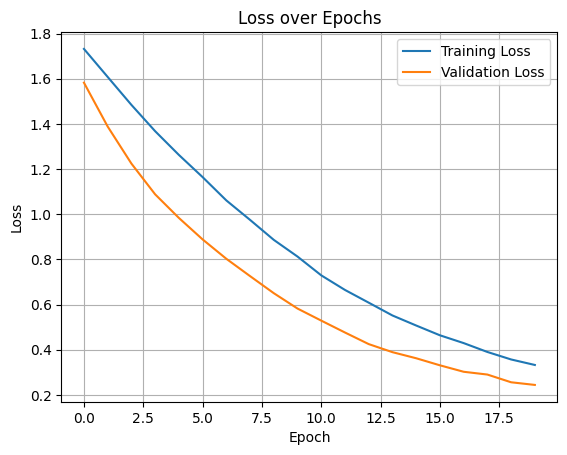

In [13]:
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

### Final Testing

In [14]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 91.67%


### Trying New Example

In [15]:
#sun_features = [5778, 1, 1, 4.83]
#sun_scaled = scaler.transform([sun_features])

temperature = float(input("Enter the star's temperature (K): "))
luminosity = float(input("Enter the star's luminosity (L): "))
radius = float(input("Enter the star's radius (R): "))
absolute_magnitude = float(input("Enter the star's absolute magnitude: "))

star_features = [temperature, luminosity, radius, absolute_magnitude]
star_scaled = scaler.transform([star_features])
input_tensor = torch.tensor(star_scaled, dtype=torch.float32).to(device)

model.eval()

with torch.no_grad():
    output = model(input_tensor)
    predicted_class = torch.argmax(output, dim=1).item()

print(f"Predicted star type class: {predicted_class}")

class_names = {
    0: 'Red Dwarf',
    1: 'Brown Dwarf',
    2: 'White Dwarf',
    3: 'Main Sequence',
    4: 'Super Giants',
    5: 'Hyper Giants'
}

print(f"Predicted star type: {class_names[predicted_class]}")

Enter the star's temperature (K): 5778
Enter the star's luminosity (L): 1
Enter the star's radius (R): 1
Enter the star's absolute magnitude: 4.83
Predicted star type class: 3
Predicted star type: Main Sequence
